# Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Loading

In [ ]:
url = 'https://drive.google.com/uc?id=1DYnW-YW49a3YRwLZ6oxhdG3HEZlL0fVu'

df_source = pd.read_csv(url)

In [ ]:
df = df_source.copy()

# Data Understanding & Data Quality Assessment

**Dataset Overview**

In [ ]:
#Preview data
df.head()

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89


In [ ]:
#Ukuran dataset
print(f"Jumlah baris : {df.shape[0]}")
print(f"Jumlah kolom : {df.shape[1]}")

Jumlah baris : 2500
Jumlah kolom : 13


In [ ]:
#Nama kolom
print(f"Daftar Kolom : {df.columns.tolist()}")

Daftar Kolom : ['Order_ID', 'Gender_Category', 'Product_Line', 'Product_Name', 'Size', 'Units_Sold', 'MRP', 'Discount_Applied', 'Revenue', 'Order_Date', 'Sales_Channel', 'Region', 'Profit']


In [ ]:
#Struktur dan Tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Size              1990 non-null   object 
 5   Units_Sold        1265 non-null   float64
 6   MRP               1246 non-null   float64
 7   Discount_Applied  832 non-null    float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        1884 non-null   object 
 10  Sales_Channel     2500 non-null   object 
 11  Region            2500 non-null   object 
 12  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 254.0+ KB


In [ ]:
#Statistik deskriptif
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order_ID,2500.0,3194.352400,749.972638,2000.00,2534.7500,3192.500,3841.2500,4499.00
Units_Sold,1265.0,1.482213,1.696947,-1.00,0.0000,2.000,3.0000,4.00
MRP,1246.0,6039.863395,2315.746826,2006.63,4038.9025,6110.030,8022.1875,9996.22
Discount_Applied,832.0,0.631022,0.365500,0.00,0.3200,0.615,0.9625,1.25
Revenue,2500.0,274.873716,2023.773550,-7561.59,0.0000,0.000,0.0000,37169.35
Profit,2500.0,1376.012848,1478.671013,-1199.45,93.5325,1371.385,2660.6450,3999.21


**Data Quality Issues**

In [ ]:
#Missing Value
pd.DataFrame({
    'Missing_value' :df.isnull().sum(),
    'Missing_value_percentage' : df.isnull().sum() / len(df) * 100
})

,Missing_value,Missing_value_percentage
Order_ID,0,0.00
Gender_Category,0,0.00
Product_Line,0,0.00
Product_Name,0,0.00
Size,510,20.40
Units_Sold,1235,49.40
MRP,1254,50.16
Discount_Applied,1668,66.72
Revenue,0,0.00
Order_Date,616,24.64


In [ ]:
#Duplicate Data
print(f"Jumlah duplikat data : {df.duplicated().sum()}")

Jumlah duplikat data : 0


In [ ]:
#Cek typo di kolom numerical dan categorical
numerical_col = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_col = df.select_dtypes(include=['object']).columns.tolist()

for col in numerical_col:
    print(df[col].value_counts())

for col in categorical_col:
  print(df[col].value_counts())

Order_ID
2030    7
2028    7
2050    6
2046    6
2003    6
       ..
2859    1
2860    1
2861    1
2862    1
2853    1
Name: count, Length: 2386, dtype: int64
Units_Sold
 2.0    234
 0.0    224
 4.0    212
-1.0    205
 1.0    203
 3.0    187
Name: count, dtype: int64
MRP
5550.99    2
3360.35    2
5048.98    1
2633.72    1
3440.57    1
          ..
2932.99    1
6495.53    1
4166.94    1
8605.73    1
7940.29    1
Name: count, Length: 1244, dtype: int64
Discount_Applied
0.90    14
1.06    13
1.02    13
0.32    12
0.47    11
        ..
0.44     3
0.79     2
0.91     2
0.92     2
0.72     1
Name: count, Length: 126, dtype: int64
Revenue
 0.00       2334
 6910.22       1
-2409.48       1
 2514.99       1
-169.59        1
            ... 
 4995.81       1
-2158.22       1
 9981.04       1
-2370.08       1
 3589.15       1
Name: count, Length: 167, dtype: int64
Profit
 2233.57    2
 1680.50    2
 1190.89    2
 3344.47    2
 2596.80    2
           ..
 2729.87    1
 2191.17    1
-990.99     1
 

In [ ]:
#Outliers

for col in numerical_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    print(f"{col}: {outliers} outliers")

Order_ID: 0 outliers
Units_Sold: 0 outliers
MRP: 0 outliers
Discount_Applied: 0 outliers
Revenue: 166 outliers
Profit: 0 outliers


Kesimpulan:
- Dataset memiliki campuran tipe data yaitu int64, float64, dan object. Kolom seperti Revenue, Profit, MRP, dan Units_Sold bertipe numerik. Sedangkan kolom seperti Region, Product_Name, dan Sales_Channel bertipe object atau teks.
- Datatype untuk Order_Date masih belum tepat (saat ini masih object)
- Rata-rata Revenue adalah 274.87 namun nilai minimumnya mencapai -7561.59 yang mengindikasikan adanya nilai negatif yang tidak wajar
- Ditemukan missing values terbanyak pada Discount_Applied (1668 / 66.72%), MRP (1254 / 50.16%), Units_Sold (1235 / 49.40%), Order_Date (616 / 24.64%), dan Size (510 / 20.40%)
- Tidak ditemukan data duplikat pada dataset ini, jumlah duplikat adalah 0.
- Ditemukan typo pada kolom Region (Hyderabad → Hyd, hyderbad) dan (Bangalore → bengaluru). Order_Date memiliki 3 format berbeda (DD-MM-YYYY, YYYY/MM/DD, YYYY-MM-DD)
- Ditemukan 166 outliers pada kolom Revenue

#Data Wrangling & Preparation Process

In [ ]:
#Check Negative Value
check_negative = df[df['Revenue'] < 0]
check_negative.count() #negative value revenue: 53

check_negative = df[df['Units_Sold'] < 0]
check_negative.count() #negative value units_sold: 205

check_negative = df[df['Profit'] < 0]
check_negative.count() #negative value profit: 578

,0
Order_ID,578
Gender_Category,578
Product_Line,578
Product_Name,578
Size,459
Units_Sold,288
MRP,295
Discount_Applied,192
Revenue,578
Order_Date,444


In [ ]:
#Invalid Discount
discGreaterThan1 = df[df['Discount_Applied'] > 1]
discGreaterThan1.count() #discount lebih besar dr 1: 180

,0
Order_ID,180
Gender_Category,180
Product_Line,180
Product_Name,180
Size,144
Units_Sold,84
MRP,87
Discount_Applied,180
Revenue,180
Order_Date,139


Cleaning & Preparing Data

In [ ]:
#Region (fix typo)
region_map = {
    'Hyd': 'Hyderabad',
    'hyderbad': 'Hyderabad',
    'bengaluru': 'Bangalore'
}
df['Region'] = df['Region'].replace(region_map)
df['Region'].unique()

array(['Bangalore', 'Hyderabad', 'Mumbai', 'Pune', 'Delhi', 'Kolkata'],
      dtype=object)

In [ ]:
#Standarize Size
size_map = {
    '6': 'S',
    '7': 'S',
    '8': 'M',
    '9': 'M',
    '10': 'L',
    '11': 'L',
    '12': 'XL'
}
df['Size'] = df['Size'].replace(size_map)
df['Size'].unique()

array(['M', 'L', 'XL', nan, 'S'], dtype=object)

In [ ]:
#Order_Date (standarize dan ubah data type)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce', format='mixed')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2500 non-null   int64         
 1   Gender_Category   2500 non-null   object        
 2   Product_Line      2500 non-null   object        
 3   Product_Name      2500 non-null   object        
 4   Size              1990 non-null   object        
 5   Units_Sold        1265 non-null   float64       
 6   MRP               1246 non-null   float64       
 7   Discount_Applied  832 non-null    float64       
 8   Revenue           2500 non-null   float64       
 9   Order_Date        1884 non-null   datetime64[ns]
 10  Sales_Channel     2500 non-null   object        
 11  Region            2500 non-null   object        
 12  Profit            2500 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(6)
memory usage: 254.0+ KB


Handle Missing Values

In [ ]:
#MRP (coba cari konteks MRP dan fill missing value based on temuannya)
mrp_check = df.groupby(['Product_Name','Region', 'Gender_Category', 'Sales_Channel'])['MRP'].nunique().reset_index(name='n_unique_mrp')
mrp_check.sort_values('n_unique_mrp', ascending=False).head(100)
#ditemukan bahwa MRP tidak konsisten di kombinasi product, region, gender_category, dan sales_channel yang sama

#handle menggunakan median per product, region, gender category, dan sales channel
#(lebih safe daripada pakai mean karena std besar)
df['MRP'] = df.groupby(['Product_Name','Region','Gender_Category','Sales_Channel'])['MRP'].transform(lambda x: x.fillna(x.median()))
df['MRP'] = df['MRP'].fillna(df['MRP'].median())
df['MRP'].isnull().sum()

np.int64(0)

In [ ]:
#Size
df['Size']=df.groupby(['Product_Name','Region','Gender_Category','Sales_Channel'])['Size'].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else x))
df['Size']=df['Size'].fillna(df['Size'].mode().iloc[0])
df['Size'].isnull().sum()

/tmp/ipykernel_2863/4091845302.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Size']=df.groupby(['Product_Name','Region','Gender_Category','Sales_Channel'])['Size'].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else x))


np.int64(0)

In [ ]:
#Discount_Applied (if revenue==MRP then no discount, fallback juga fillna(0))
mask = df['Discount_Applied'].isna() & (df['Revenue'] == df['MRP'])
df.loc[mask, 'Discount_Applied'] = 0
df['Discount_Applied'] = df['Discount_Applied'].fillna(0)
df['Discount_Applied'].isnull().sum()

np.int64(0)

In [ ]:
#Units_Sold
#gabisa derive dari revenue krn tidak ada data tentang unit price (Revenue = Units_Sold x Selling_Price)
#ambil median dari groupby product_name, region, dan sales_channel utk mempertahankan local sales pattern
df['Units_Sold'] = df.groupby(['Product_Name','Region','Sales_Channel'])['Units_Sold'].transform(lambda x: x.fillna(x[x>0].median()))
df['Units_Sold'] = df.groupby(['Product_Name'])['Units_Sold'].transform(lambda x: x.fillna(x[x>0].median()))
df['Units_Sold'] = df['Units_Sold'].fillna(df[df['Units_Sold']>0]['Units_Sold'].median())
df['Units_Sold'].isnull().sum()

np.int64(0)

In [ ]:
#Order_Date(pilih modus per region dan product_line)
df['Order_Date'] = df.groupby(['Region', 'Product_Line'])['Order_Date'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))
df['Order_Date'] = df['Order_Date'].fillna(df['Order_Date'].mode()[0])
df['Order_Date'].isnull().sum()

np.int64(0)

In [ ]:
pd.DataFrame({
    'Missing_value' :df.isnull().sum(),
    'Missing_value_percentage' : df.isnull().sum() / len(df) * 100
})

,Missing_value,Missing_value_percentage
Order_ID,0,0.0
Gender_Category,0,0.0
Product_Line,0,0.0
Product_Name,0,0.0
Size,0,0.0
Units_Sold,0,0.0
MRP,0,0.0
Discount_Applied,0,0.0
Revenue,0,0.0
Order_Date,0,0.0


In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Order_ID,2500.0,3194.3524,2000.0,2534.75,3192.5,3841.25,4499.0,749.972638
Units_Sold,2500.0,1.9612,-1.0,1.0,2.0,3.0,4.0,1.439279
MRP,2500.0,6029.778104,2006.63,4494.8575,6077.13,7543.755,9996.22,2032.339808
Discount_Applied,2500.0,0.210004,0.0,0.0,0.0,0.32,1.25,0.364519
Revenue,2500.0,274.873716,-7561.59,0.0,0.0,0.0,37169.35,2023.77355
Order_Date,2500,2024-11-09 08:18:14.400000,2023-07-26 00:00:00,2024-08-10 18:00:00,2024-11-22 00:00:00,2025-03-22 00:00:00,2025-12-07 00:00:00,NaN
Profit,2500.0,1376.012848,-1199.45,93.5325,1371.385,2660.645,3999.21,1478.671013


Handle Anomalies & Outlier

In [ ]:
#Negative Units_Sold, Revenue, Profit, dan Discount_Applied

#invalid units_sold
mask_invalid_units=(df['Units_Sold']==0)&(df['Revenue']==0)&(df['Profit']!=0)

#invalid revenue (negatif tapi units positif)
mask_invalid_revenue=(df['Revenue']<0)&(df['Units_Sold']>0)

#invalid discount
mask_invalid_discount=(df['Discount_Applied']>1)

#invalid profit
mask_invalid_profit=(df['Profit']>df['Revenue'])&(df['Revenue']>0)

In [ ]:
df.loc[mask_invalid_units, 'Units_Sold'] = None
df.loc[mask_invalid_revenue,'Revenue']=None
df.loc[mask_invalid_discount,'Discount_Applied']=None
df.loc[mask_invalid_profit,'Profit']=None

In [ ]:
df['Units_Sold'].isnull().sum()

np.int64(224)

In [ ]:
#Revenue (handle outlier)
#tidak jadi karena sampai dengan q3 pun revenue masih 0, justru revenue yg selain 0
#akan dianggap outlier kalau dilakukan proses ini
# Q1 = df['Revenue'].quantile(0.25)
# Q3 = df['Revenue'].quantile(0.75)
# IQR = Q3-Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# df['Revenue']=df['Revenue'].clip(lower,upper)

In [ ]:
#Final Check
#Anomalies
print("Neg Units:",(df['Units_Sold']<0).sum())
print("Neg Revenue:",(df['Revenue']<0).sum())
print("Neg Profit:",(df['Profit']<0).sum())
print("Discount > 1:",(df['Discount_Applied']>1).sum())

#Missing Value
print(df.isnull().sum())

Neg Units: 205
Neg Revenue: 23
Neg Profit: 578
Discount > 1: 0
Order_ID              0
Gender_Category       0
Product_Line          0
Product_Name          0
Size                  0
Units_Sold          224
MRP                   0
Discount_Applied    180
Revenue              30
Order_Date            0
Sales_Channel         0
Region                0
Profit               10
dtype: int64


In [ ]:
#Re-impute

#Units_Sold
df.dropna(subset=['Units_Sold'], inplace=True)

#Discount_Applied
df['Discount_Applied']=df['Discount_Applied'].fillna(0)

#Recalculate revenue
df['Revenue_recalc']=df['Units_Sold']*df['MRP']*(1-df['Discount_Applied'])

#Replace invalid revenue
df['Revenue'] = df['Revenue'].fillna(df['Revenue_recalc'])

#Profit
df['Profit']=df.groupby(['Product_Name','Region','Sales_Channel'])['Profit'].transform(lambda x:x.fillna(x.median()))
df['Profit']=df.groupby(['Product_Name'])['Profit'].transform(lambda x:x.fillna(x.median()))
df['Profit']=df['Profit'].fillna(df['Profit'].median())

#Casting Units_Sold jadi INT
df['Units_Sold'] = df['Units_Sold'].astype(int)

In [ ]:
#Missing Value
print(df.isnull().sum())

Order_ID            0
Gender_Category     0
Product_Line        0
Product_Name        0
Size                0
Units_Sold          0
MRP                 0
Discount_Applied    0
Revenue             0
Order_Date          0
Sales_Channel       0
Region              0
Profit              0
Revenue_recalc      0
dtype: int64


In [ ]:
#Drop invalid return
#masih ditemukan ada units_sold == -1, revenue <0, tapi profit > 0
mask_invalid_return=(df['Units_Sold']==-1)&((df['Revenue_recalc']>0)|(df['Profit']>0))
df = df[~mask_invalid_return]

In [ ]:
#FINAL CHECKKK
#Anomalies
print("Neg Units:",(df['Units_Sold']<0).sum())
print("Neg Revenue:",(df['Revenue_recalc']<0).sum())
print("Neg Profit:",(df['Profit']<0).sum())
print("Discount > 1:",(df['Discount_Applied']>1).sum())

#Missing Value
print(df.isnull().sum())

Neg Units: 44
Neg Revenue: 44
Neg Profit: 527
Discount > 1: 0
Order_ID            0
Gender_Category     0
Product_Line        0
Product_Name        0
Size                0
Units_Sold          0
MRP                 0
Discount_Applied    0
Revenue             0
Order_Date          0
Sales_Channel       0
Region              0
Profit              0
Revenue_recalc      0
dtype: int64


In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Order_ID,2115.0,3199.145154,2000.0,2541.5,3188.0,3846.5,4499.0,748.783344
Units_Sold,2115.0,2.340898,-1.0,2.0,2.0,3.0,4.0,1.093806
MRP,2115.0,6050.237884,2006.63,4522.345,6077.13,7561.225,9996.22,2016.994026
Discount_Applied,2115.0,0.122355,0.0,0.0,0.0,0.01,1.0,0.254641
Revenue,2115.0,604.02834,-7561.59,0.0,0.0,0.0,37169.35,3032.606779
Order_Date,2115,2024-11-08 23:04:51.063829760,2023-07-26 00:00:00,2024-08-09 00:00:00,2024-11-20 00:00:00,2025-03-25 12:00:00,2025-12-07 00:00:00,NaN
Profit,2115.0,1335.208787,-1199.45,8.365,1345.26,2635.29,3999.21,1500.433727
Revenue_recalc,2115.0,12613.688148,-9701.91,6332.1675,11465.18,18231.39,39984.88,8498.38409


In [ ]:
# df.to_csv('df_clean2.csv', index=False, float_format='%.2f')

Data Transformation dan Derived Variable yang Dibuat

In [ ]:
df['is_return']=(df['Units_Sold']<0)&(df['Revenue_recalc']<0)&(df['Profit']<0)

In [ ]:
#Time Features
df['year']=df['Order_Date'].dt.year
df['month']=df['Order_Date'].dt.month
df['day']=df['Order_Date'].dt.day
df['day_of_week']=df['Order_Date'].dt.day_name()

In [ ]:
#Profit Margin
df['profit_margin']=df.apply(
    lambda x: x['Profit']/x['Revenue_recalc'] if x['Revenue_recalc']>0 else None,
    axis=1
)

In [ ]:
#Revenue per Unit
df['revenue_per_unit']=df.apply(
    lambda x: x['Revenue_recalc']/x['Units_Sold'] if x['Units_Sold']>0 else None,
    axis=1
)

In [ ]:
df.to_csv('df_clean3.csv', index=False, float_format='%.2f')

In [ ]:
#+Revenue_recalc dibagian Re-impute

In [ ]:
df.head()

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,...,Region,Profit,Revenue_recalc,is_return,year,month,day,day_of_week,profit_margin,revenue_per_unit
0,2000,Kids,Training,SuperRep Go,M,3,4321.685,0.47,0.0,2024-03-09,...,Bangalore,-770.45,6871.47915,False,2024,3,9,Saturday,-0.112123,2290.49305
1,2001,Women,Soccer,Tiempo Legend,M,3,4957.930,0.00,0.0,2024-07-09,...,Hyderabad,-112.53,14873.79000,False,2024,7,9,Tuesday,-0.007566,4957.93000
2,2002,Women,Soccer,Premier III,M,4,8534.070,0.00,0.0,2025-07-11,...,Mumbai,3337.34,34136.28000,False,2025,7,11,Friday,0.097765,8534.07000
3,2003,Kids,Lifestyle,Blazer Mid,L,3,9673.570,0.00,0.0,2024-04-10,...,Pune,3376.85,29020.71000,False,2024,4,10,Wednesday,0.116360,9673.57000
4,2004,Kids,Running,React Infinity,XL,3,6077.130,0.00,0.0,2024-09-12,...,Delhi,187.89,18231.39000,False,2024,9,12,Thursday,0.010306,6077.13000


In [ ]:
df.shape

(2115, 21)

#Exploratory Data Analysis (EDA)

Descriptive Statistics

In [ ]:
df = df.drop(columns=['Order_ID', 'Revenue'])
numerical_col = df.select_dtypes(include=['int64','float64', 'int32']).columns.tolist()
categorical_col = df.select_dtypes(include=['object', 'bool']).columns.tolist()

In [ ]:
# descriptive statistics
stats = pd.DataFrame({
    'mean': df.mean(numeric_only=True),
    'median': df.median(numeric_only=True),
    'min': df.min(numeric_only=True),
    'max': df.max(numeric_only=True),
    'std': df.std(numeric_only=True),
    'var': df.var(numeric_only=True)
})

print(stats)

                          mean        median       min        max  \
Units_Sold            2.340898      2.000000        -1          4   
MRP                6050.237884   6077.130000   2006.63    9996.22   
Discount_Applied      0.122355      0.000000       0.0        1.0   
Profit             1335.208787   1345.260000  -1199.45    3999.21   
Revenue_recalc    12613.688148  11465.180000  -9701.91   39984.88   
is_return             0.020804      0.000000     False       True   
year               2024.342790   2024.000000      2023       2025   
month                 6.707329      7.000000         1         12   
day                  15.150355     15.000000         1         31   
profit_margin         0.245909      0.106497 -8.383466  50.516643   
revenue_per_unit   5474.481863   5571.140000       0.0   14523.69   

                          std           var  
Units_Sold           1.093806  1.196411e+00  
MRP               2016.994026  4.068265e+06  
Discount_Applied     0.254641  6.

Visualize distributions and comparisons

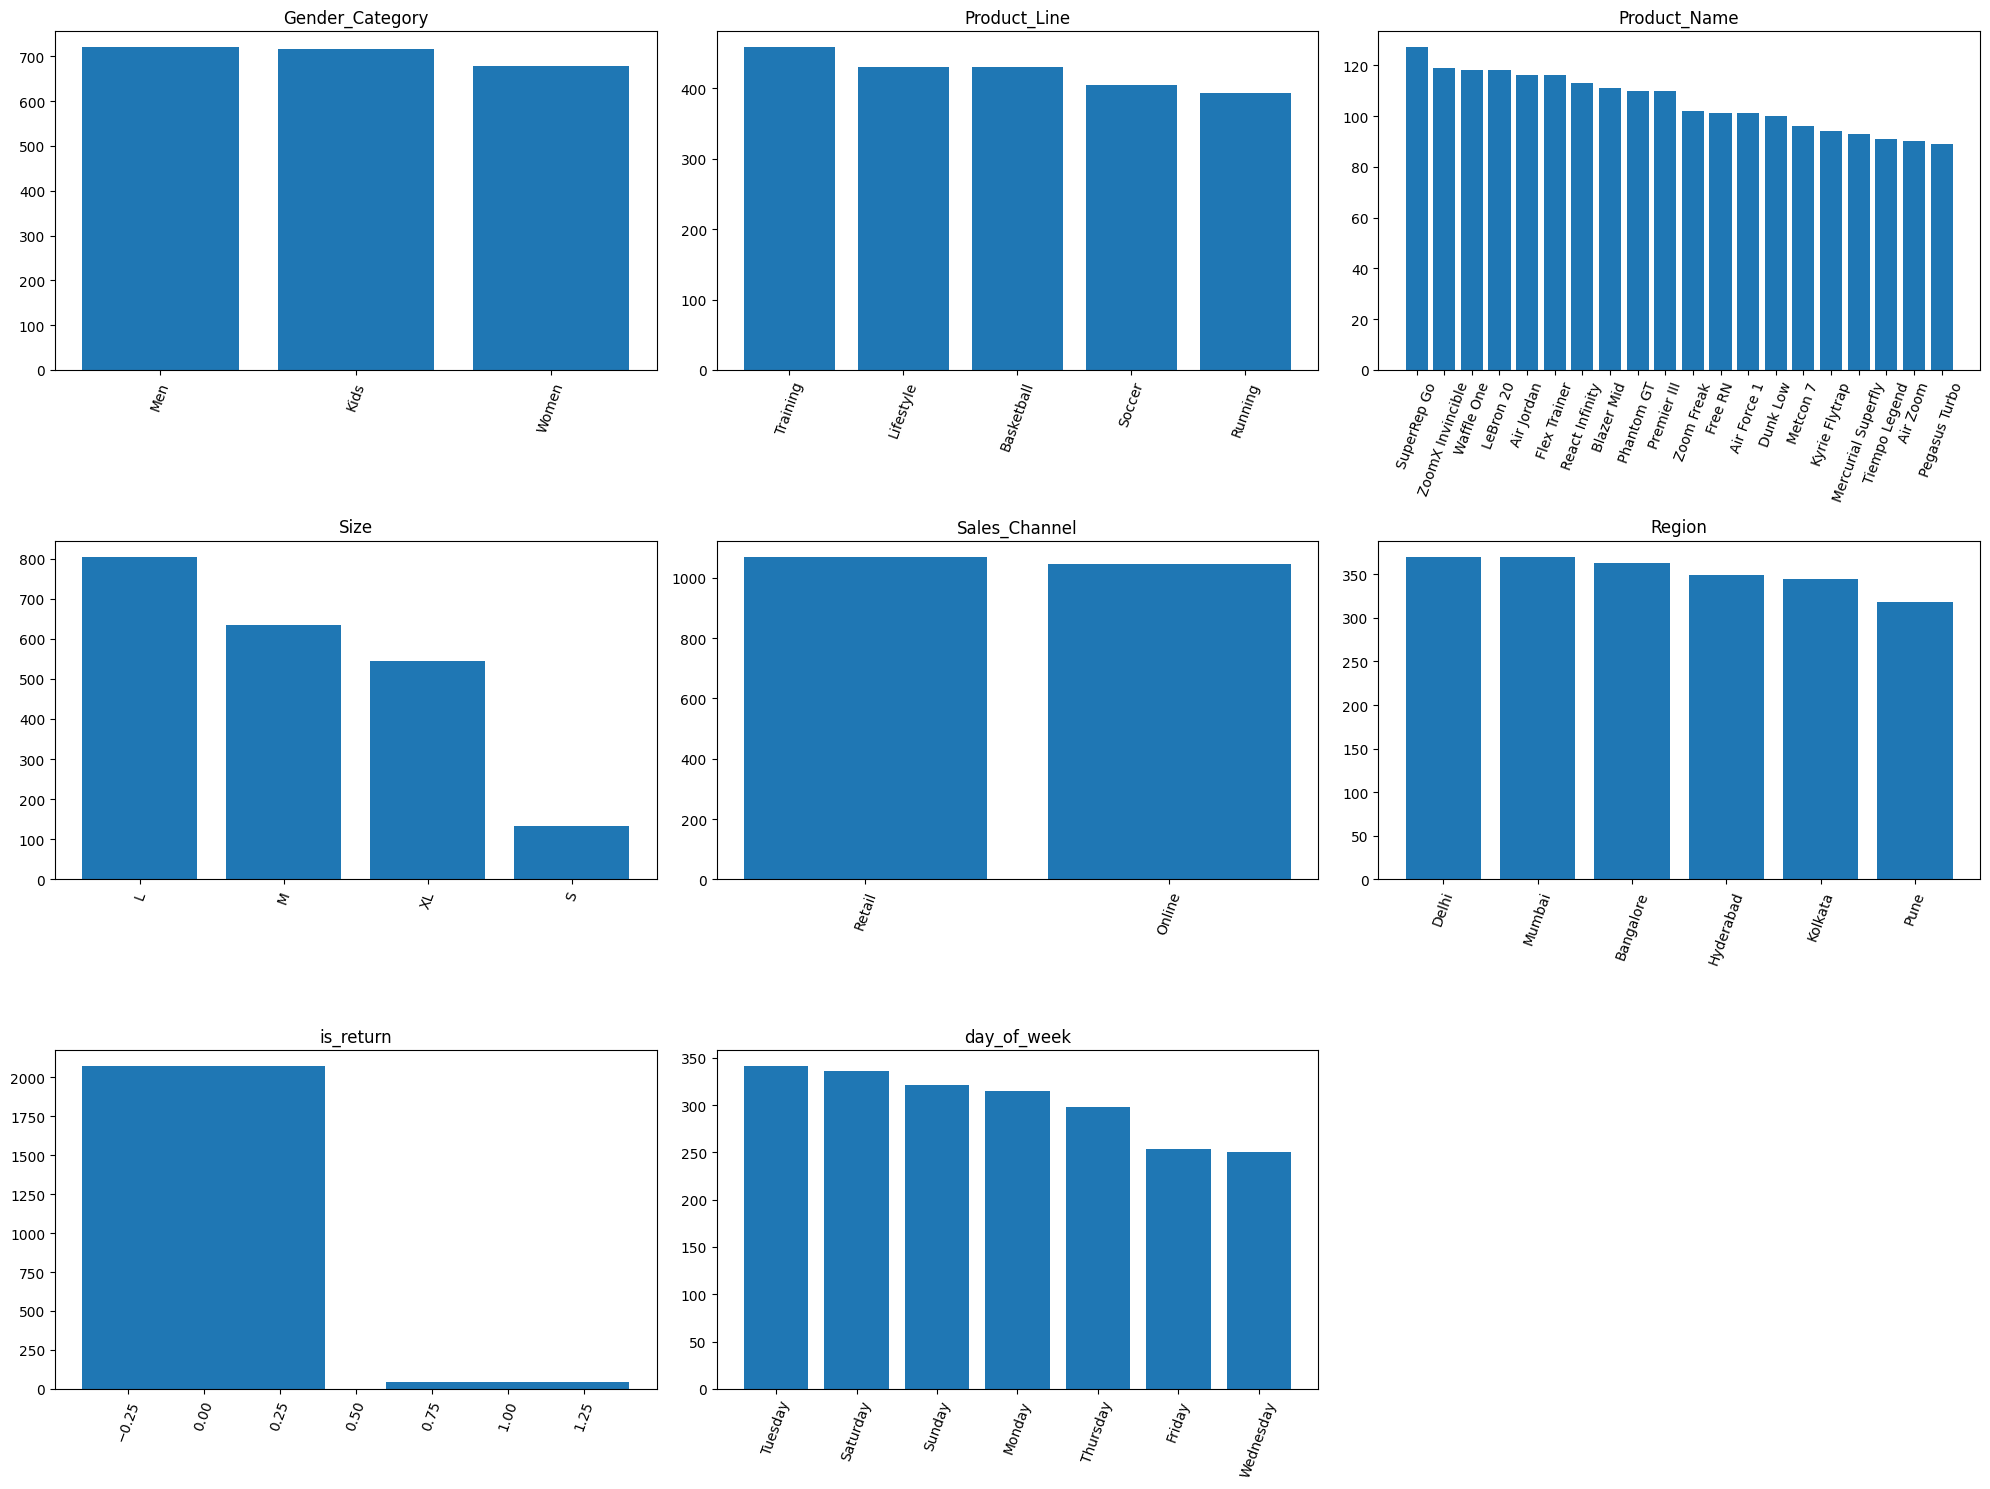

In [ ]:
def visual_categories(df, catCols):
  n = len(catCols)
  rows = -(-n//3)
  plt.figure(figsize=(20, 15))

  for i, col in enumerate(catCols, 1):
    plt.subplot(rows, 3, i)
    counts = df[col].value_counts()
    plt.bar(counts.index, counts.values)
    plt.title(col)
    plt.xticks(rotation=70)

  plt.tight_layout()
  plt.show()

visual_categories(df, categorical_col)

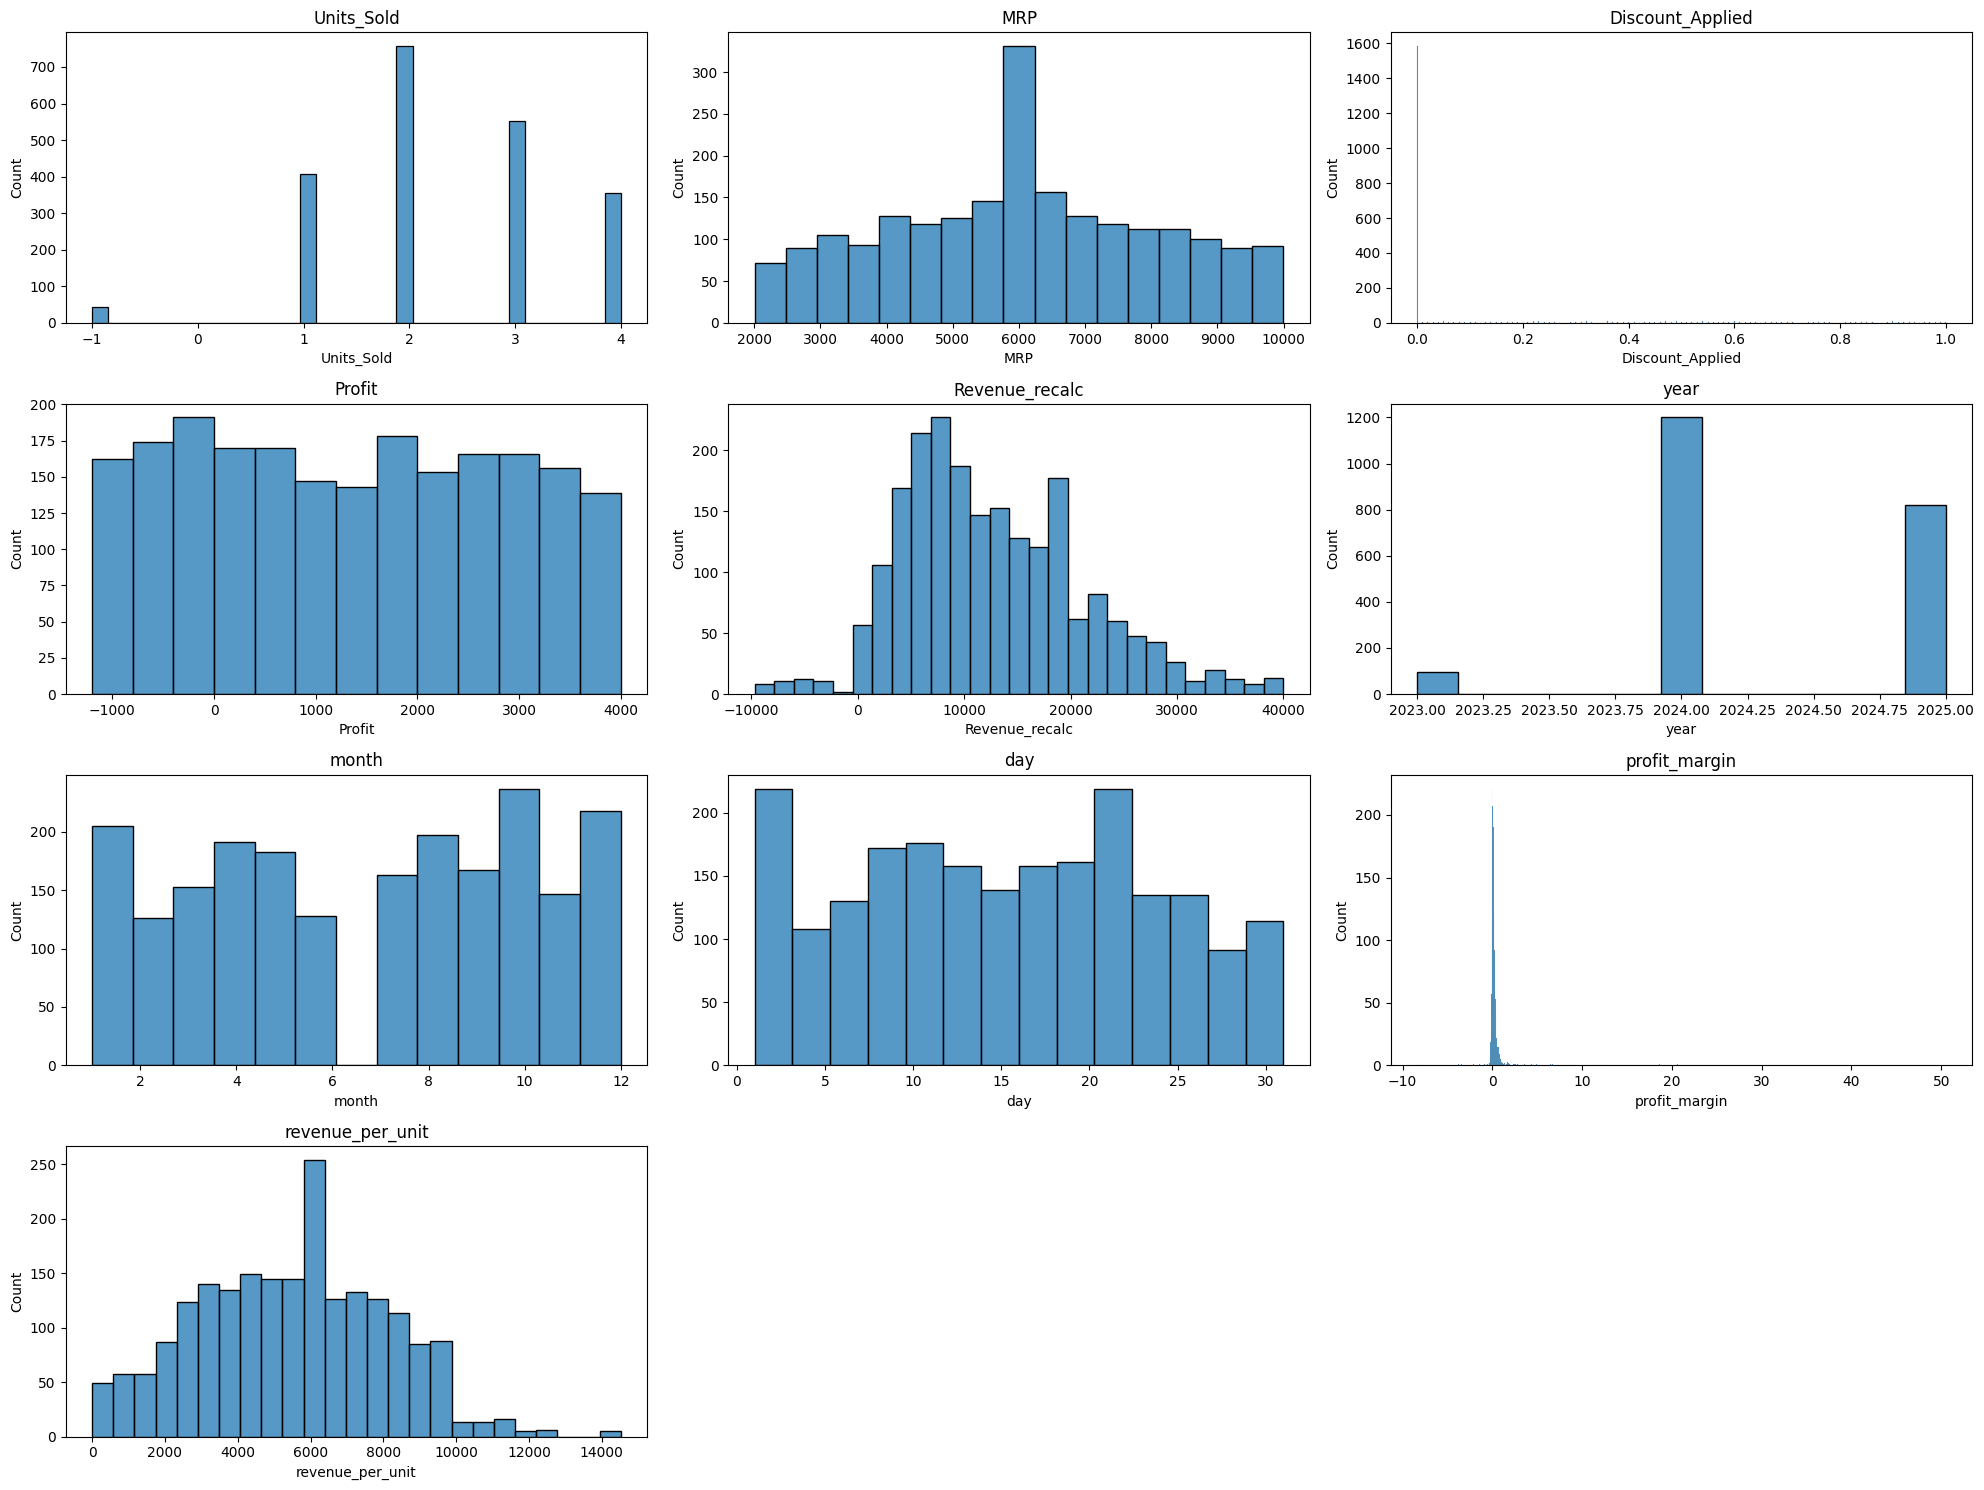

In [ ]:
def visual_numerical(df, numCols):
  n = len(numCols)
  rows = -(-n//3)
  plt.figure(figsize=(20, 15))

  for i, col in enumerate(numCols, 1):
    plt.subplot(rows, 3, i)
    sns.histplot(x=df[col])
    plt.title(col)

  plt.tight_layout()
  plt.show()

visual_numerical(df, numerical_col)

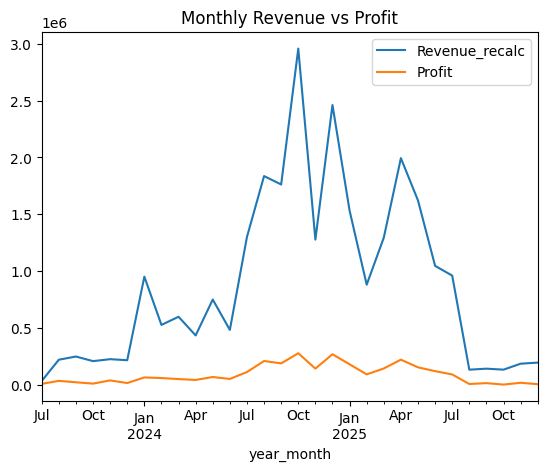

In [ ]:
df['year_month'] = df['Order_Date'].dt.to_period('M')
df_monthly = df.groupby('year_month')[['Revenue_recalc','Profit']].sum()
df_monthly.index = df_monthly.index.to_timestamp()

df_monthly.plot()
plt.title("Monthly Revenue vs Profit")
plt.show()

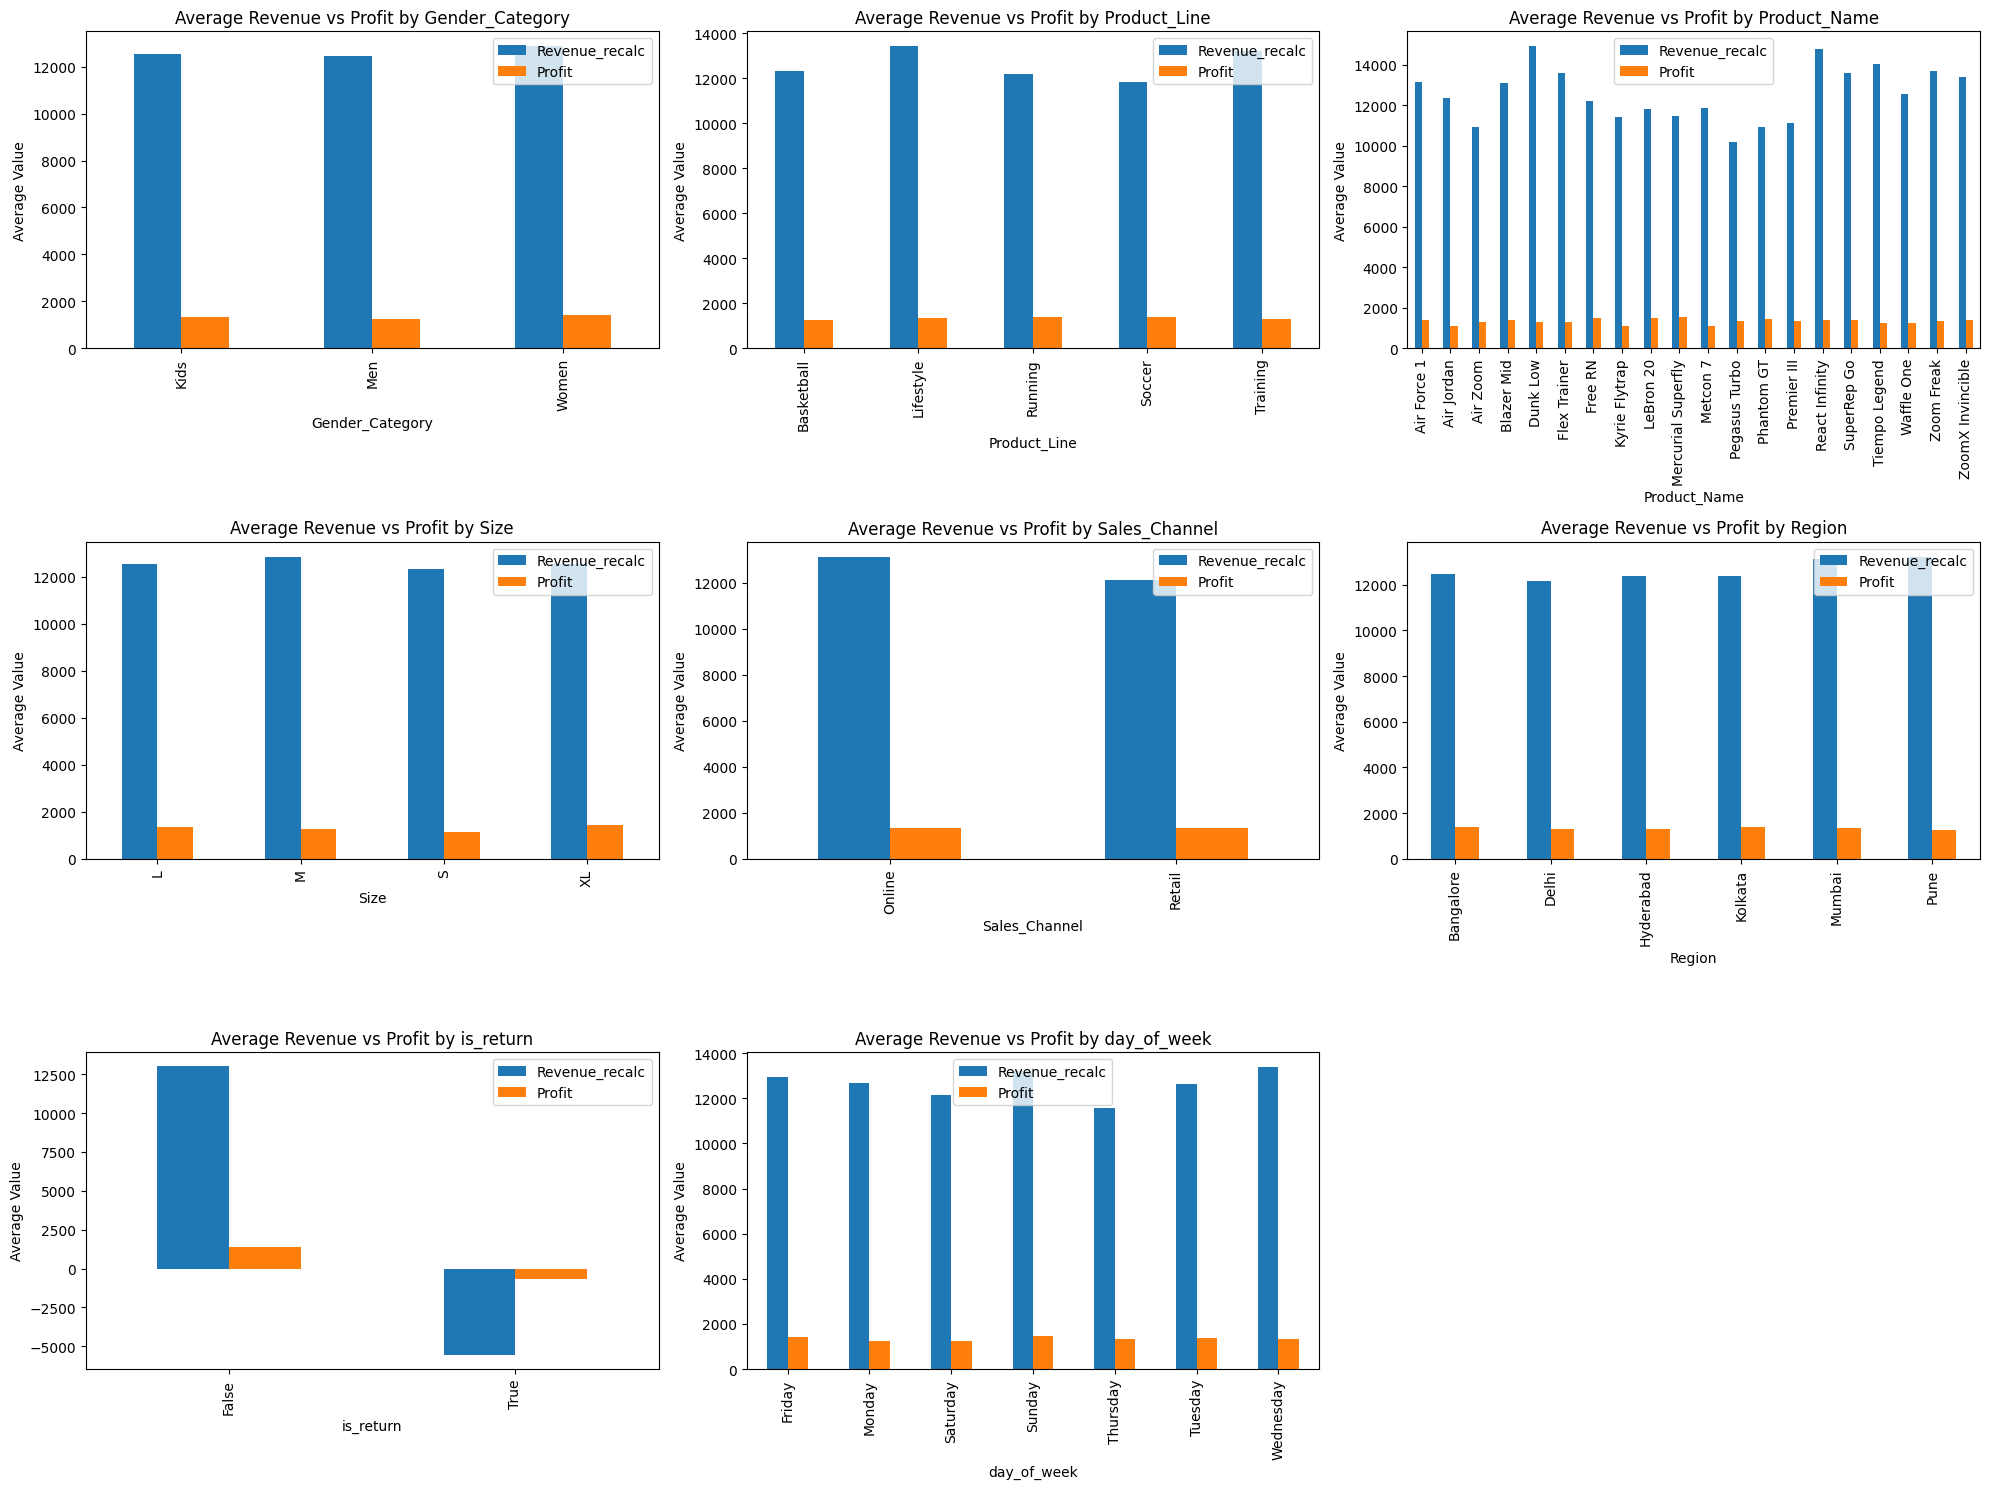

In [ ]:
def comparisons(df, catCols):
  n = len(catCols)
  rows = -(-n//3)
  plt.figure(figsize=(20,15))


  for i, col in enumerate(catCols, 1):
    plt.subplot(rows, 3 ,i)
    df_cat = df.groupby(col)[['Revenue_recalc','Profit']].mean().reset_index()

    df_cat.plot(kind='bar', x=col, ax=plt.gca())

    # plt.plot(df_cat[col], df_cat['Revenue'], label='Avg Revenue')
    # plt.plot(df_cat[col], df_cat['Profit'], label='Avg Profit')

    plt.title(f"Average Revenue vs Profit by {col}")
    plt.xlabel(col)
    plt.ylabel("Average Value")
    plt.legend()
    # plt.xticks(rotation=90)

  plt.tight_layout()
  plt.show()

catCols = [cat for cat in categorical_col if cat != 'Order_Date']
comparisons(df, catCols)

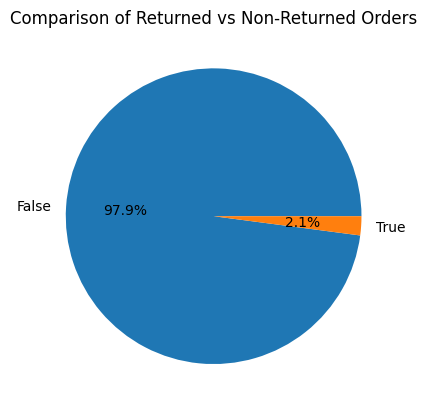

In [ ]:
return_counts = df['is_return'].value_counts()

plt.figure()
plt.pie(return_counts, labels=return_counts.index, autopct='%1.1f%%')

plt.title("Comparison of Returned vs Non-Returned Orders")
plt.show()